<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [73]:
df = pd.read_csv("./data/College.csv")
df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [74]:
df.rename(columns = {df.columns[0]: "College Name"}, inplace = True)
df.head(2)

,College Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [75]:
df.shape

(777, 19)

In [76]:
df.dtypes

College Name        str
Private             str
Apps              int64
Accept            int64
Enroll            int64
Top10perc         int64
Top25perc         int64
F.Undergrad       int64
P.Undergrad       int64
Outstate          int64
Room.Board        int64
Books             int64
Personal          int64
PhD                 str
Terminal          int64
S.F.Ratio       float64
perc.alumni       int64
Expend            int64
Grad.Rate         int64
dtype: object

In [77]:
df.isnull().sum()

College Name    0
Private         0
Apps            0
Accept          0
Enroll          0
Top10perc       0
Top25perc       0
F.Undergrad     0
P.Undergrad     0
Outstate        0
Room.Board      0
Books           0
Personal        0
PhD             0
Terminal        0
S.F.Ratio       0
perc.alumni     0
Expend          0
Grad.Rate       0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [78]:
df["PhD"].value_counts()

PhD
?      29
77     26
73     24
90     22
71     21
       ..
32      1
14      1
103     1
26      1
16      1
Name: count, Length: 78, dtype: int64

In [79]:
df["PhD"].describe()

count     777
unique     78
top         ?
freq       29
Name: PhD, dtype: object

In [80]:
df["PhD"] = df["PhD"].replace("?", np.nan)
df["PhD"] = pd.to_numeric(df["PhD"])

In [81]:
phd_median = df['PhD'].median()
df['PhD'] = df['PhD'].fillna(phd_median)
df['PhD'].describe()

count    777.000000
mean      72.611326
std       16.014355
min        8.000000
25%       62.000000
50%       75.000000
75%       85.000000
max      103.000000
Name: PhD, dtype: float64

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [82]:
# Your code here
df["Grad.Rate"].value_counts()

Grad.Rate
72    24
67    23
63    22
58    22
65    21
      ..
22     1
32     1
27     1
10     1
30     1
Name: count, Length: 81, dtype: int64

In [83]:
df["Grad.Rate"].describe()

count    777.00000
mean      65.46332
std       17.17771
min       10.00000
25%       53.00000
50%       65.00000
75%       78.00000
max      118.00000
Name: Grad.Rate, dtype: float64

In [85]:
df['Grad.Rate'] = df['Grad.Rate'].clip(upper=100)
df['Grad.Rate'].describe()

count    777.000000
mean      65.440154
std       17.118804
min       10.000000
25%       53.000000
50%       65.000000
75%       78.000000
max      100.000000
Name: Grad.Rate, dtype: float64

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [86]:
%%writefile myutils.py
import pandas as pd
import numpy as np

def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 
    rows = []
    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        n_unique = df[col].nunique()
    
        if n_unique <= 2 or n_unique == len(df):
            continue

        skewness = df[col].skew()

        if skewness > 0:
            direction = 'Positive'
        elif skewness < 0:
            direction = 'Negative'
        else:
            direction = 'Symmetrical'

        abs_skew = abs(skewness)
        if abs_skew <= 0.5:
            degree = 'Approximately Symmetric'
        elif abs_skew <= 1.0:
            degree = 'Moderately Skewed'
        else:
            degree = 'Highly Skewed'

        if degree == 'Approximately Symmetric':
            transformation = 'None needed'
        elif col.lower() == 'perc.alumni':
            transformation = 'log(x+1) or Yeo-Johnson'
        else:
            transformation = 'Box-Cox or Yeo-Johnson'

        rows.append({
            'Feature': col,
            'Skewness': skewness,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': transformation
        })

    return pd.DataFrame(rows)

Overwriting myutils.py


In [87]:
# Now import the function from myutils

In [88]:
def plot_transformations(df, skew_table):
    """
    Plots original vs. best transformed distributions side by side, 
    matching the exact title styles from the assignment workspace.
    """
    # Filter out columns that don't need any transformation
    cols_to_transform = skew_table[skew_table['Recommended Transformation'] != 'None needed']
    
    for _, row in cols_to_transform.iterrows():
        feature = row['Feature']
        original_data = df[feature].dropna()
        
        # Test candidate transformations to programmatically find the absolute best one
        candidates = {}
        
        # 1. Log Transform (only if all values > 0)
        if original_data.min() > 0:
            candidates['Log'] = np.log(original_data)
            
        # 2. Log Plus One
        candidates['Log Plus One'] = np.log1p(original_data)
        
        # 3. Box-Cox (only if all values > 0)
        if original_data.min() > 0:
            try:
                bc_data, _ = stats.boxcox(original_data)
                candidates['Box-Cox'] = bc_data
            except Exception:
                pass
                
        # 4. Yeo-Johnson (handles 0 and negative values safely)
        try:
            yj_data, _ = stats.yeojohnson(original_data)
            candidates['Yeo-Johnson'] = yj_data
        except Exception:
            pass

        # Evaluate which transformation got the absolute skew closest to 0
        best_trans_name = None
        best_trans_data = None
        min_abs_skew = float('inf')
        
        for name, data in candidates.items():
            current_skew = abs(stats.skew(data))
            if current_skew < min_abs_skew:
                min_abs_skew = current_skew
                best_trans_name = name
                best_trans_data = data
                
        if best_trans_data is not None:
            orig_skew_val = original_data.skew()
            new_skew_val = pd.Series(best_trans_data).skew()
            
            # Setup side-by-side subplots matching the reference layout
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            # Left Subplot: Original Data
            sns.histplot(original_data, kde=True, ax=axes[0], color='#72a3cc', edgecolor='black', linewidth=0.5)
            axes[0].set_title(f"Original {feature}\n(Skew: {orig_skew_val:.2f})")
            axes[0].set_xlabel(feature)
            axes[0].set_ylabel("Count")
            
            # Right Subplot: Transformed Data
            sns.histplot(best_trans_data, kde=True, ax=axes[1], color='#72a3cc', edgecolor='black', linewidth=0.5)
            axes[1].set_title(f"Best transformation: {best_trans_name} for {feature}\n(Skew: {new_skew_val:.2f})")
            axes[1].set_xlabel("") # Matches the empty/omitted x-label on the right plots
            axes[1].set_ylabel("Count")
            
            plt.tight_layout()
            plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [89]:
# Your code here
from myutils import skew_calc

skewness = skew_calc(df)
skewness

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


In [90]:
# Your code here

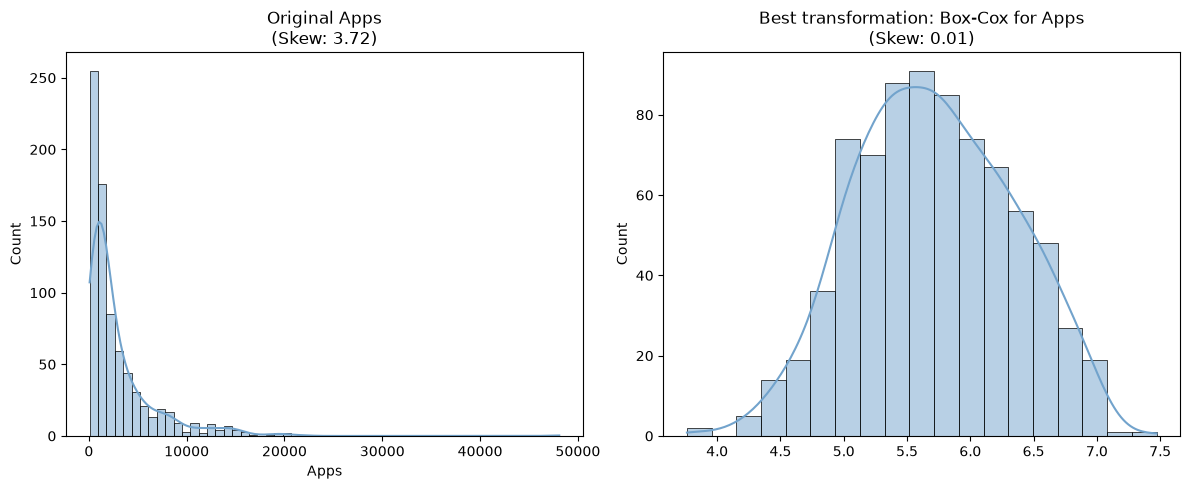

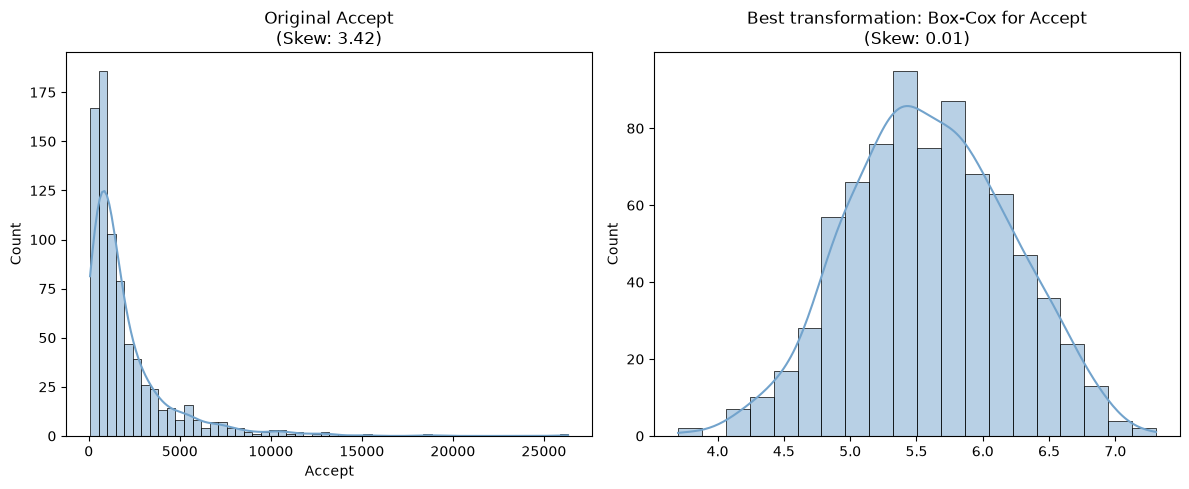

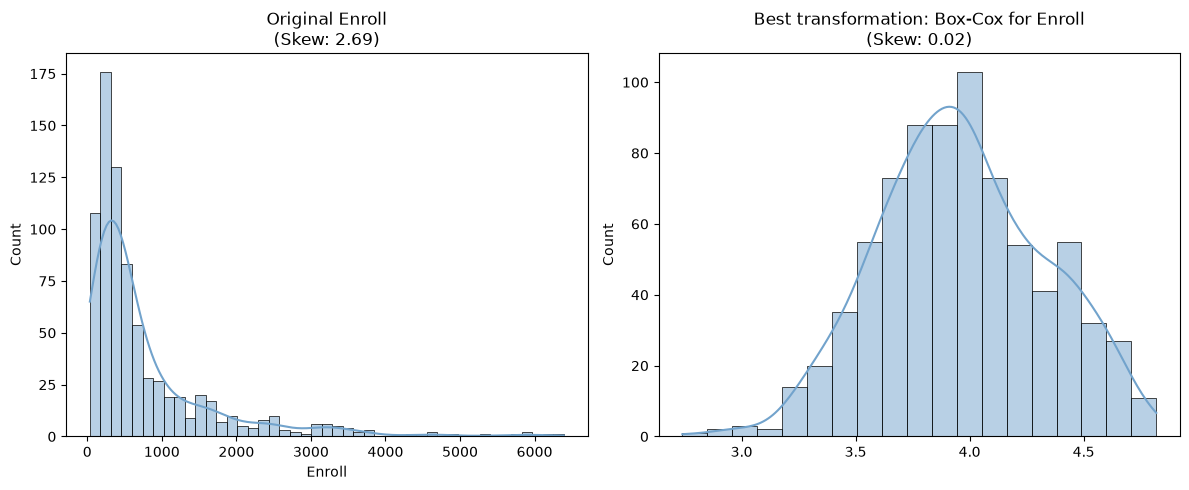

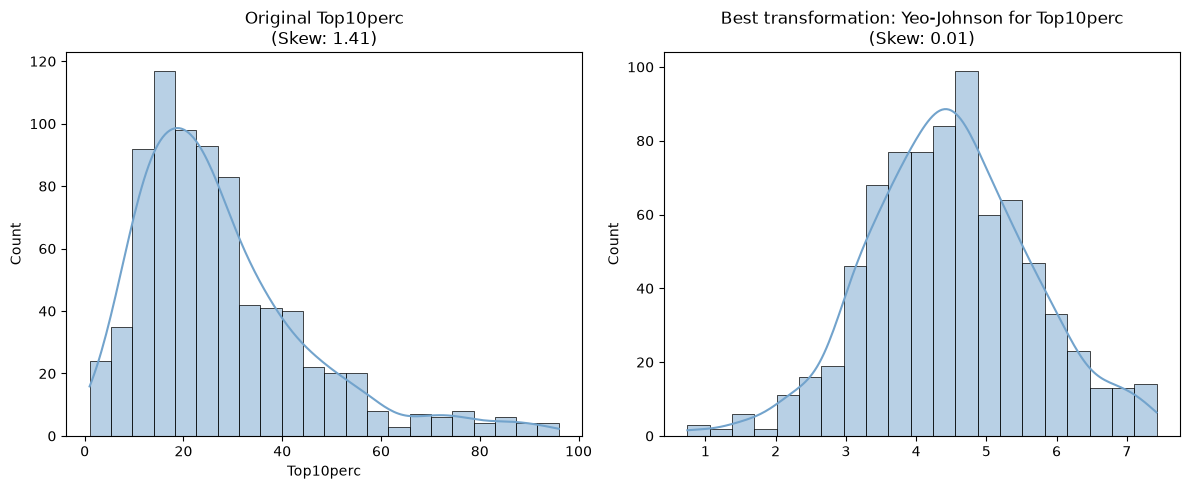

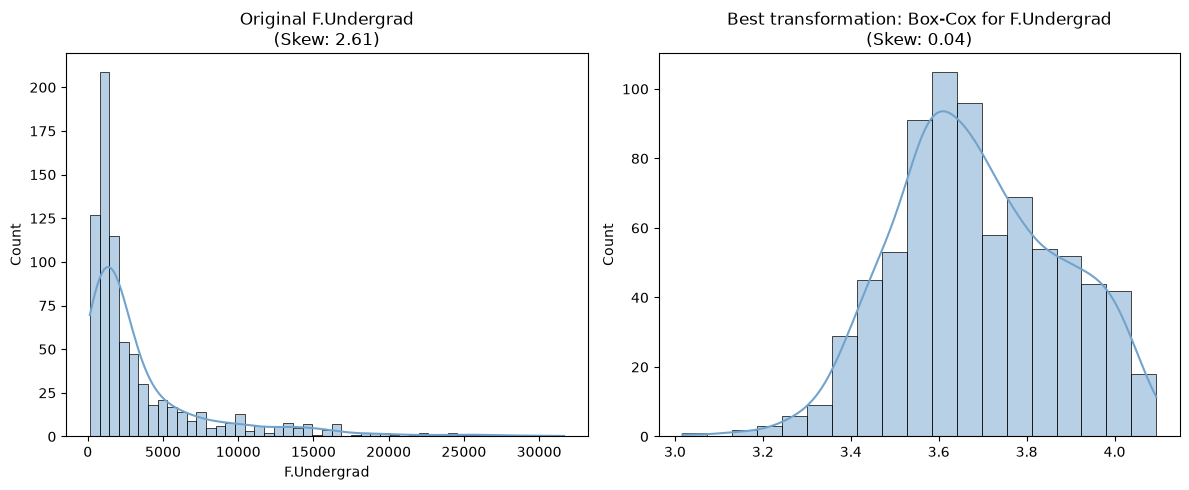

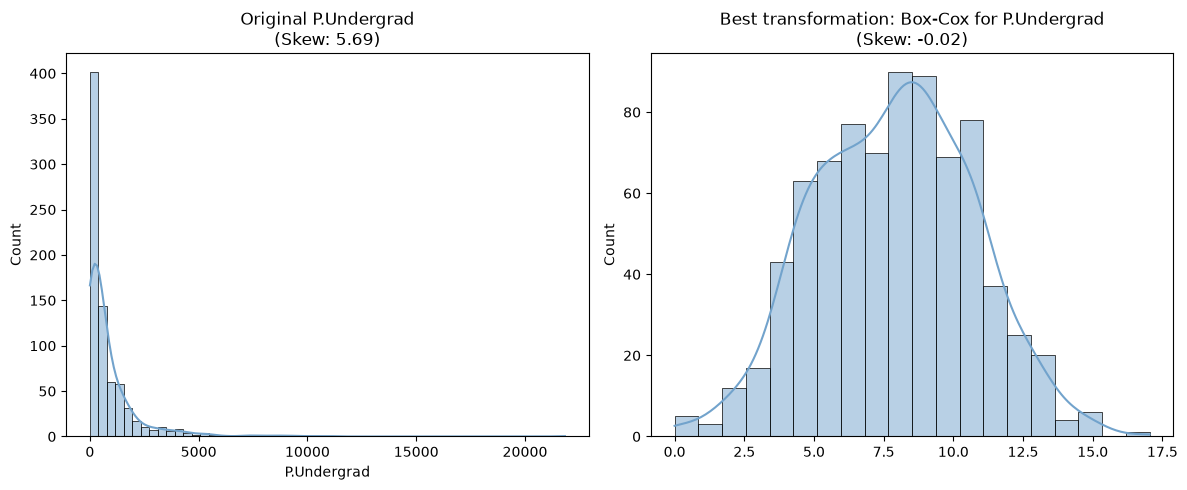

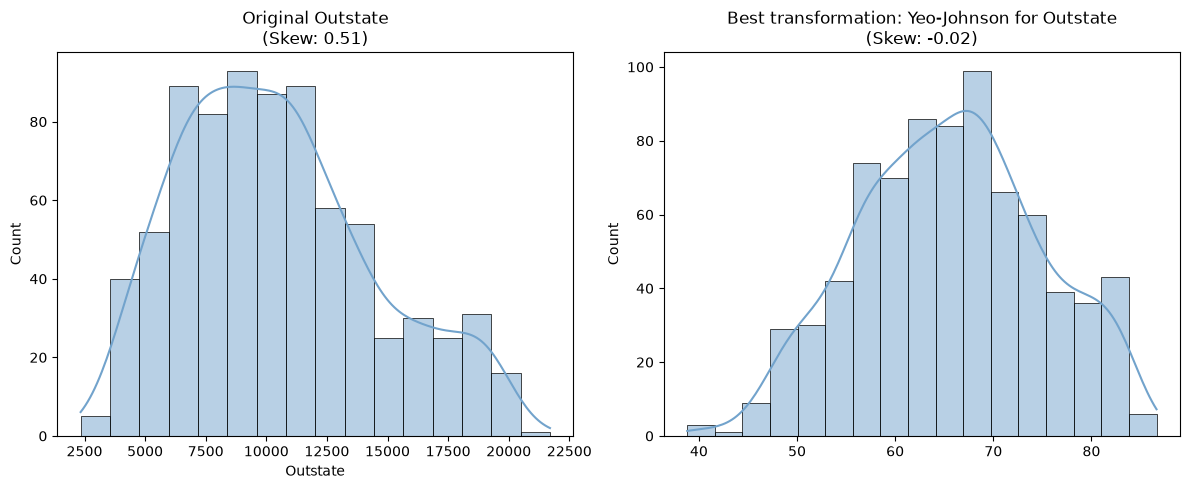

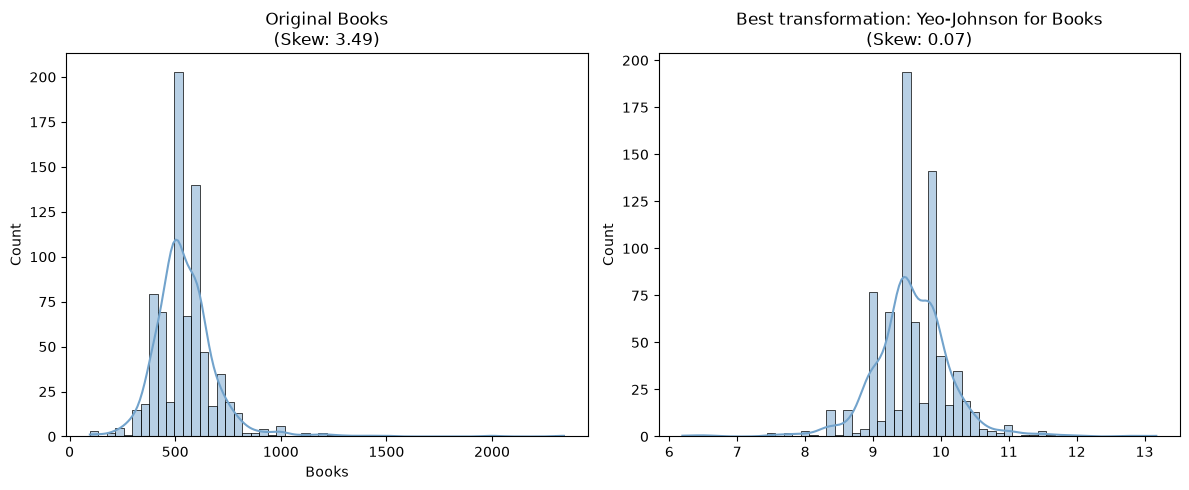

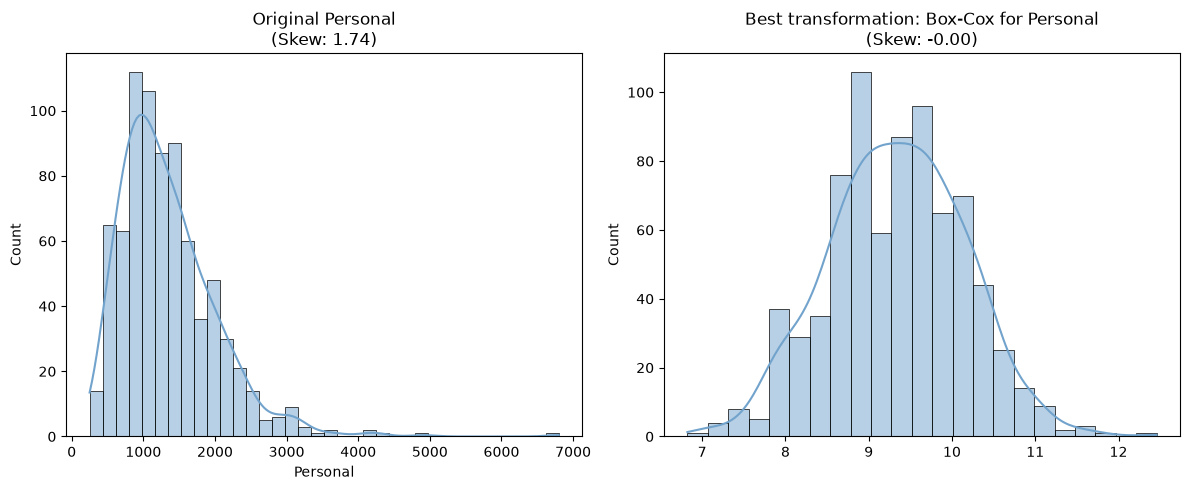

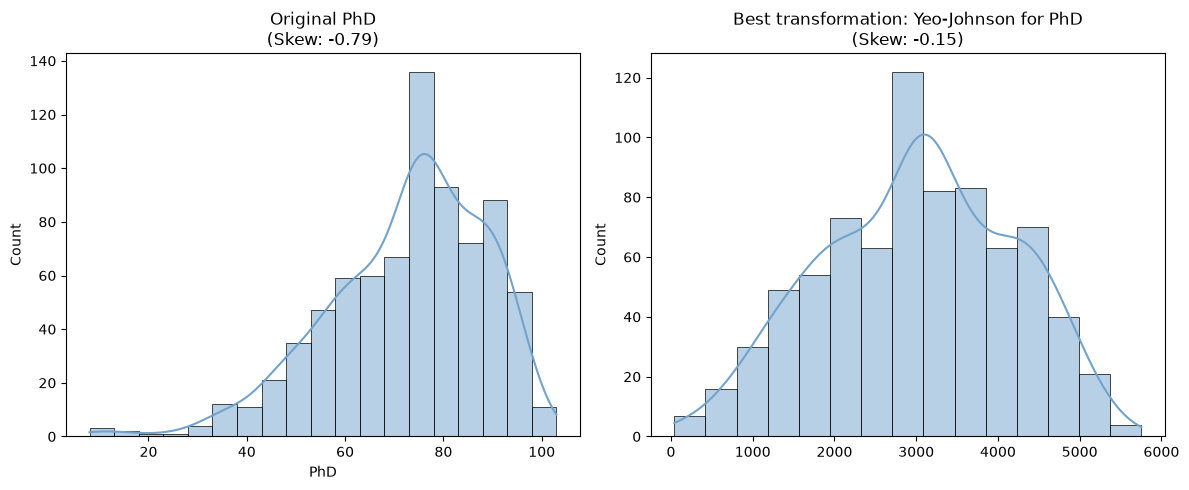

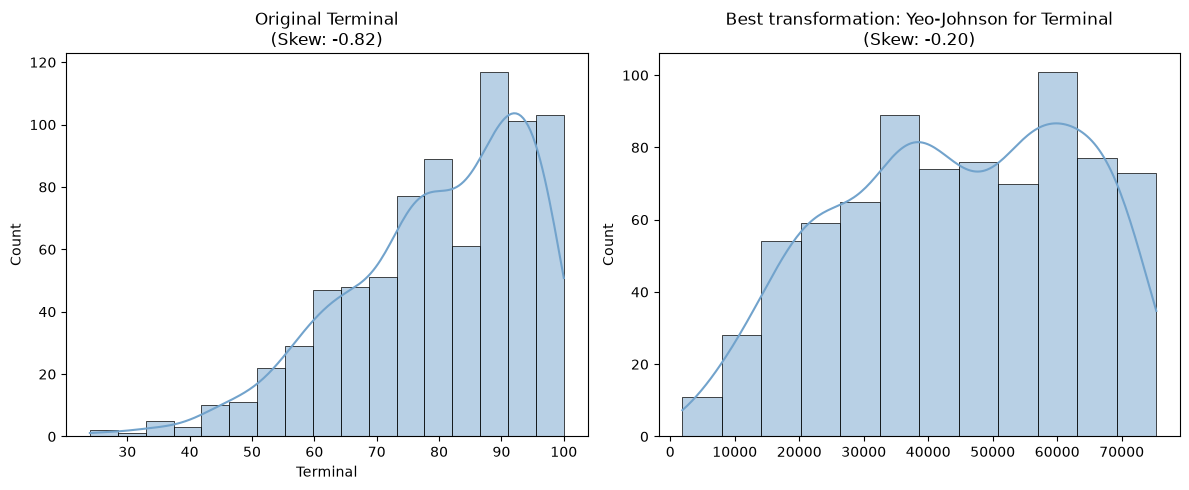

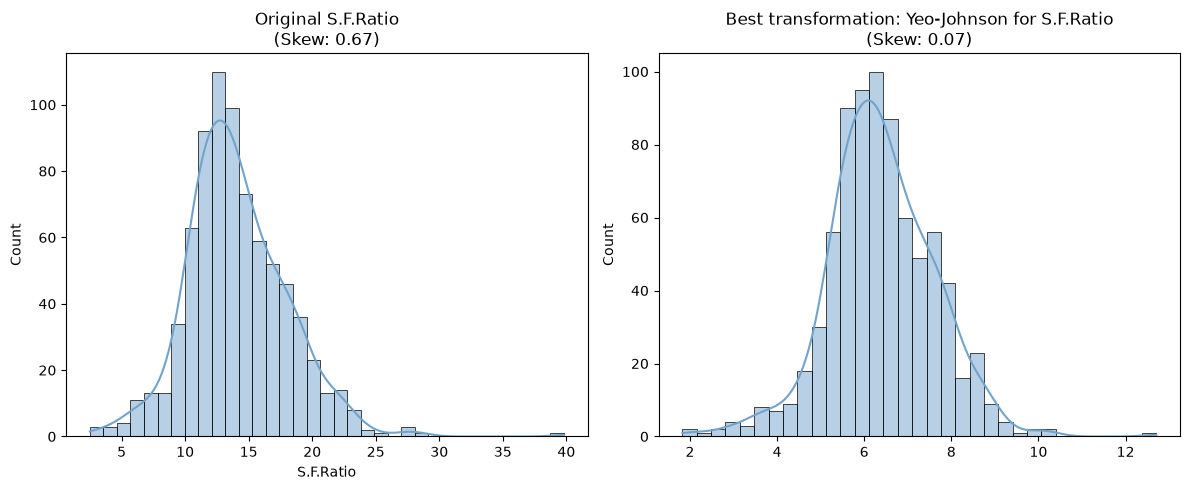

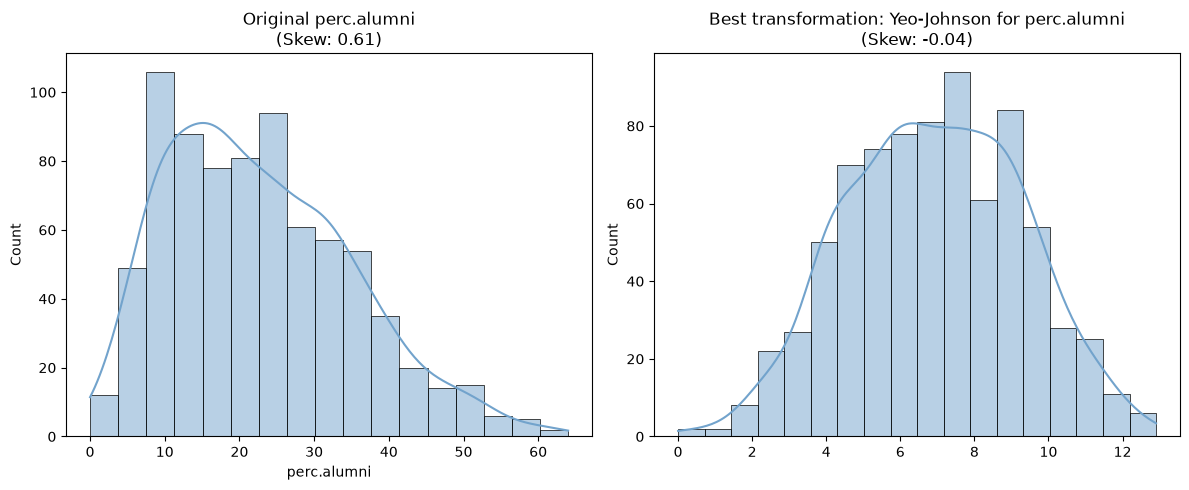

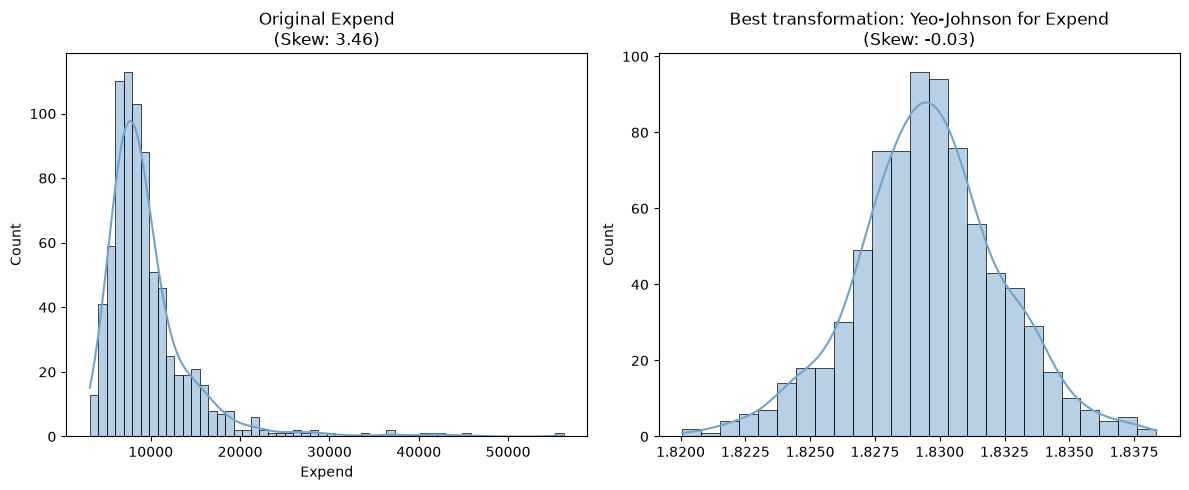

In [91]:
# Your code here
plot_transformations(df, skewness)

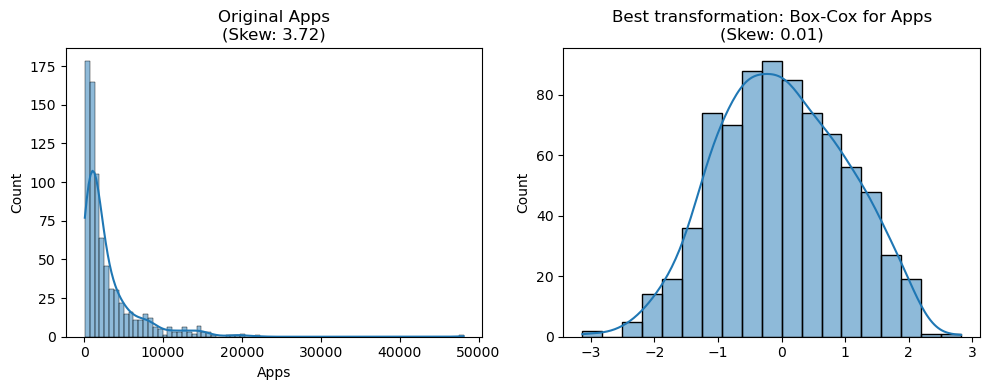

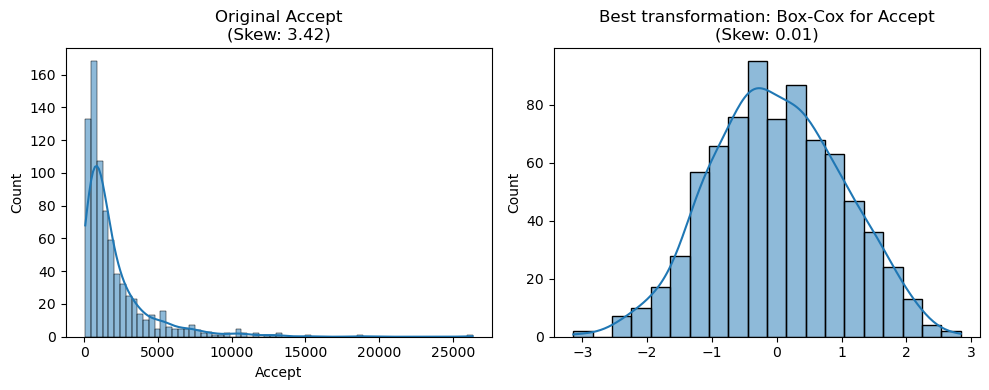

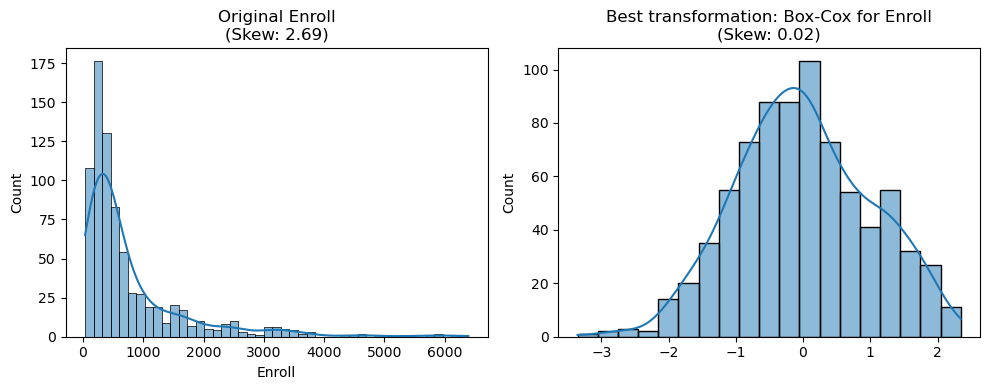

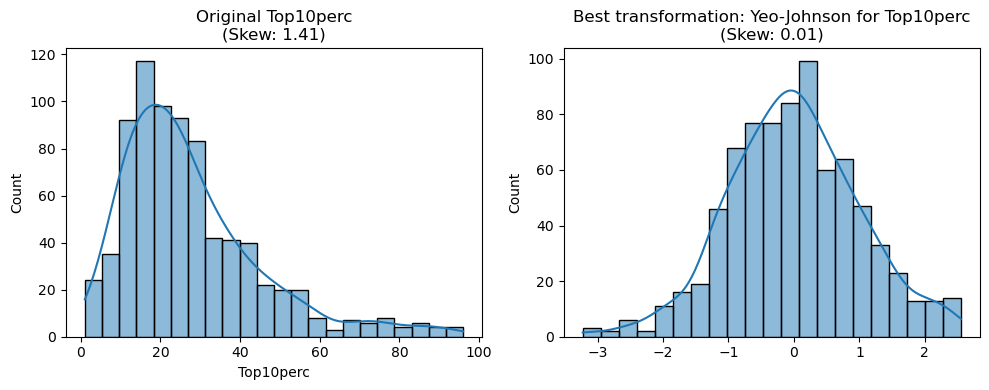

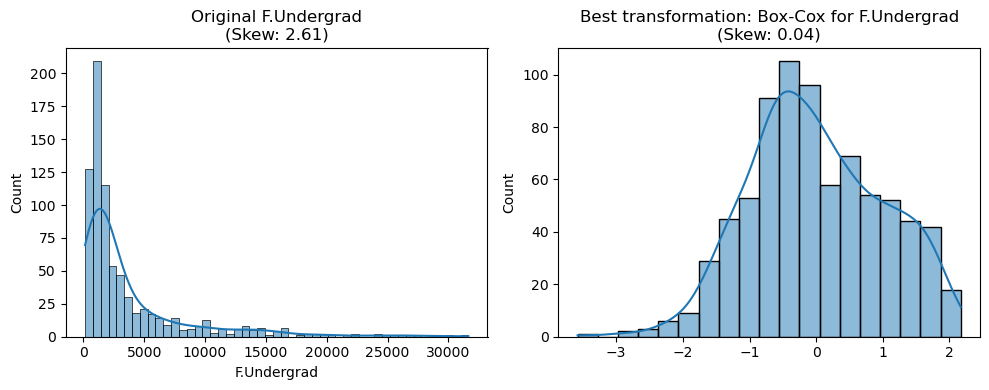

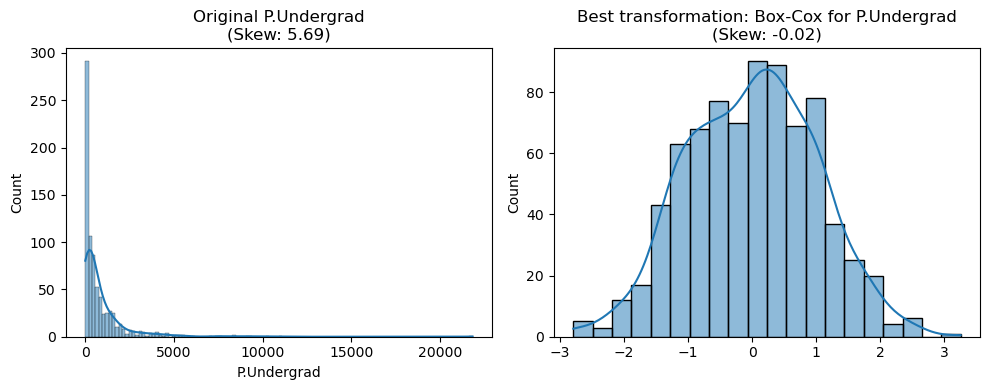

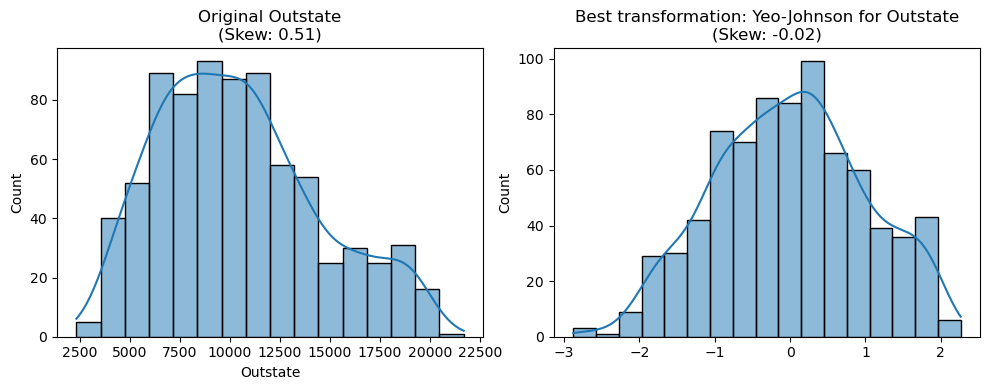

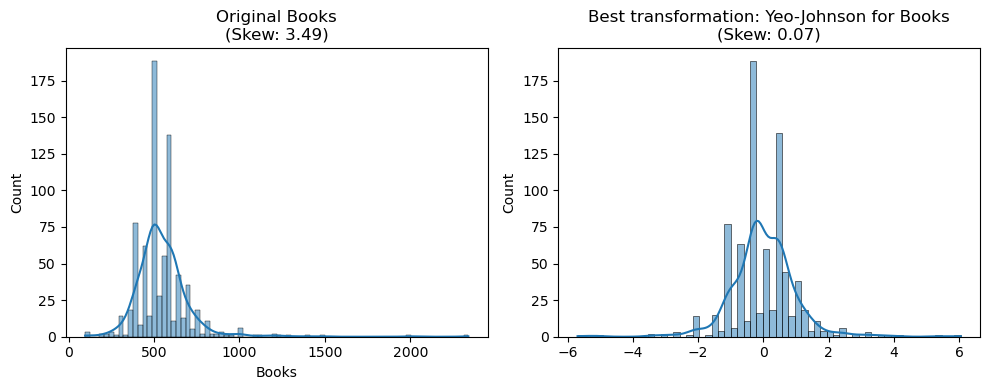

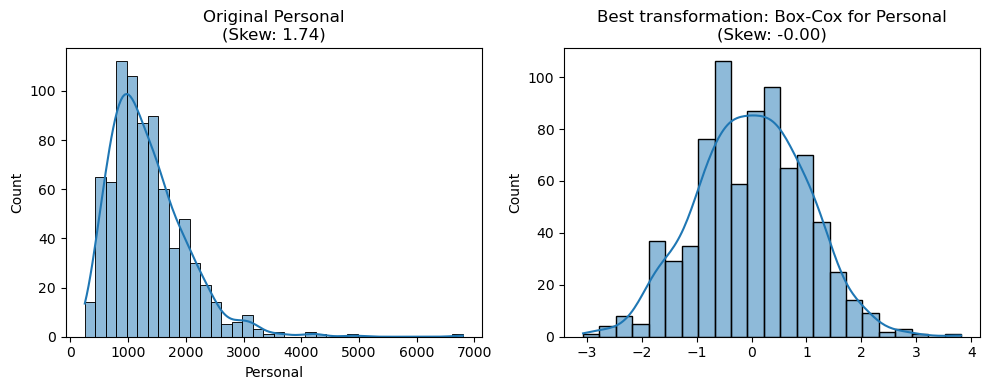

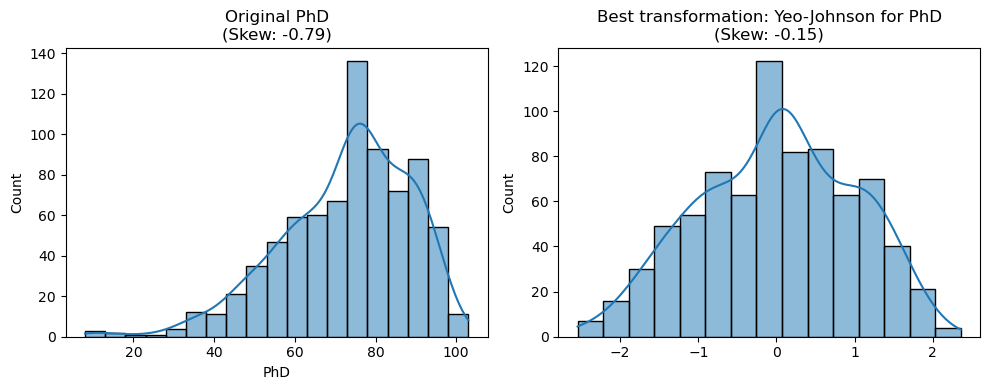

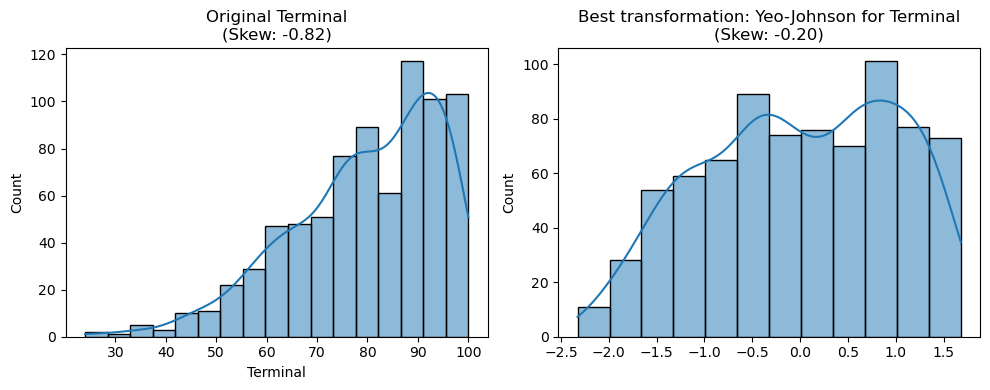

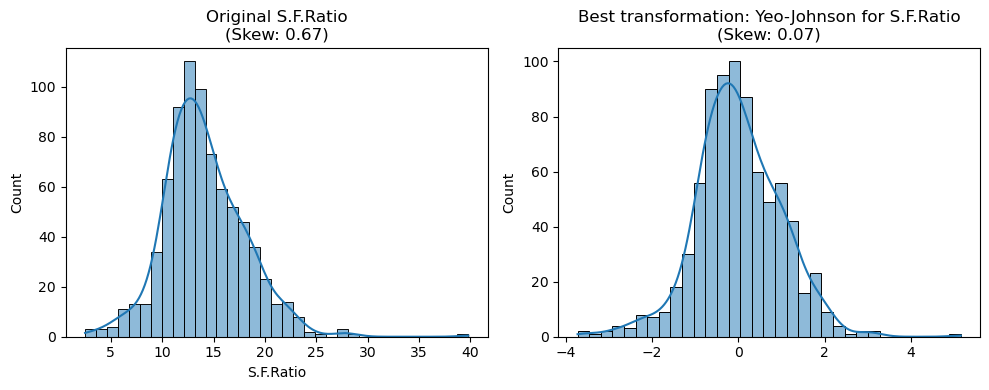

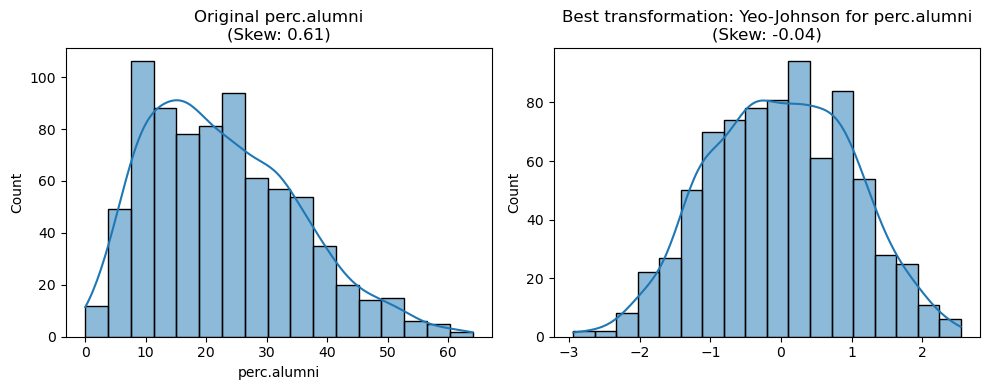

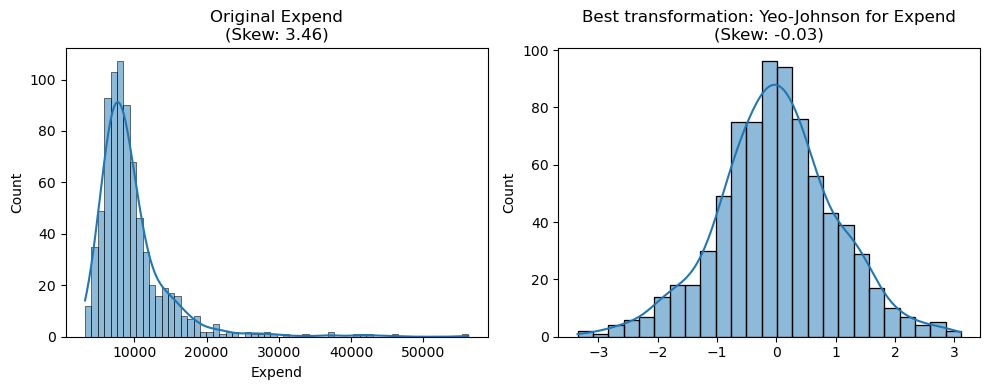

In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [92]:

# Your code here 

from scipy import stats

trans_cols = []

for i in range(len(skewness)):
    feature = skewness.loc[i, 'Feature']
    degree = skewness.loc[i, 'Degree']
    recommendation = skewness.loc[i, 'Recommended Transformation']

    if degree == 'Highly Skewed' or degree == 'Moderately Skewed':
        new_col_name = f'{feature}_trans'

        if 'log(x+1)' in recommendation:
            df[new_col_name] = np.log1p(df[feature])
            trans_cols.append(new_col_name)
            
        elif 'Box-Cox' in recommendation:
            if df[feature].min() > 0:
                df[new_col_name], _ = stats.boxcox(df[feature])
            else:
                df[new_col_name], _ = stats.yeojohnson(df[feature])
            trans_cols.append(new_col_name)

print(trans_cols)

['Apps_trans', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 'F.Undergrad_trans', 'P.Undergrad_trans', 'Outstate_trans', 'Books_trans', 'Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Expend_trans']


## Part D: Feature Engineering and Encoding

In [93]:
df.head()

,College Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,3.769302,8.713915,59.142209,9.288880,10.374877,2378.818582,34148.774234,7.965493,2.564949,1.828730
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,3.756515,10.316290,70.781897,10.448462,9.706972,410.687774,2801.807925,5.909038,2.833213,1.831689
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,3.568664,5.815935,68.600055,9.032160,9.276476,1366.447300,22055.928365,6.170678,3.433987,1.830396
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,3.401005,5.119856,72.157160,9.288880,8.798545,4100.645683,60412.083923,4.059557,3.637586,1.835020
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,3.202743,9.631371,59.483775,10.600468,9.706972,2802.381707,27695.561321,5.795125,1.098612,1.831929


#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [94]:
# Your code here 
df['Accept_Rate'] = df['Accept'] / df['Apps']
df.head()

,College Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans,Accept_Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,8.713915,59.142209,9.288880,10.374877,2378.818582,34148.774234,7.965493,2.564949,1.828730,0.742169
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,10.316290,70.781897,10.448462,9.706972,410.687774,2801.807925,5.909038,2.833213,1.831689,0.880146
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,5.815935,68.600055,9.032160,9.276476,1366.447300,22055.928365,6.170678,3.433987,1.830396,0.768207
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,5.119856,72.157160,9.288880,8.798545,4100.645683,60412.083923,4.059557,3.637586,1.835020,0.836930
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,9.631371,59.483775,10.600468,9.706972,2802.381707,27695.561321,5.795125,1.098612,1.831929,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [95]:
# Your code here 
df['Outstate_Tier'] = pd.cut(df['Outstate'], bins=3, labels=['Low', 'Medium', 'High'])
df.head()

,College Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans,Accept_Rate,Outstate_Tier
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,59.142209,9.288880,10.374877,2378.818582,34148.774234,7.965493,2.564949,1.828730,0.742169,Low
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,70.781897,10.448462,9.706972,410.687774,2801.807925,5.909038,2.833213,1.831689,0.880146,Medium
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,68.600055,9.032160,9.276476,1366.447300,22055.928365,6.170678,3.433987,1.830396,0.768207,Medium
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,72.157160,9.288880,8.798545,4100.645683,60412.083923,4.059557,3.637586,1.835020,0.836930,Medium
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,59.483775,10.600468,9.706972,2802.381707,27695.561321,5.795125,1.098612,1.831929,0.756477,Low


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [96]:
# Your code here 
df['Outstate_Tier_Encoded'] = df['Outstate_Tier'].cat.codes
df.head(1)

,College Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans,Accept_Rate,Outstate_Tier,Outstate_Tier_Encoded
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,9.28888,10.374877,2378.818582,34148.774234,7.965493,2.564949,1.82873,0.742169,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [97]:
# Your code here 
df['Private_Encoded'] = df['Private'].map({'Yes': 1, 'No': 0})
df.head(1)

,College Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans,Accept_Rate,Outstate_Tier,Outstate_Tier_Encoded,Private_Encoded
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,10.374877,2378.818582,34148.774234,7.965493,2.564949,1.82873,0.742169,Low,0,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [98]:
cols_to_scale = []
cols_to_scale = trans_cols + ['Accept_Rate','Outstate_Tier_Encoded','Private_Encoded']

# Your code here 
ss = StandardScaler()

scaled_col_names = [f"{col}_scaled" for col in cols_to_scale]

df[scaled_col_names] = ss.fit_transform(df[cols_to_scale])

df.head(2)

,College Name,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Accept_Rate_scaled,Outstate_Tier_Encoded_scaled,Private_Encoded_scaled
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,-0.614254,1.271398,-0.290788,-0.282374,1.017946,-0.722701,-0.491183,-0.032372,-1.098797,0.612553
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,1.302365,0.456551,-2.179258,-2.248129,-0.435083,-0.284489,0.552362,0.906193,0.358140,0.612553


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

In [110]:
# Your code here 

cols_to_drop = ['College Name',
    'Apps', 'Accept', 'Enroll', 'Top10perc', 'F.Undergrad', 'P.Undergrad', 
    'Outstate', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 
    'perc.alumni', 'Expend', 'Private',
    'Apps_trans', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 
    'F.Undergrad_trans', 'P.Undergrad_trans', 'Outstate_trans', 'Books_trans', 
    'Personal_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 
    'Expend_trans',
    'Outstate_Tier', 'Unnamed: 0'
]


df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

print("Polished features ready for modeling:")
print(df_cleaned.columns.tolist())

Polished features ready for modeling:
['Top25perc', 'Room.Board', 'Grad.Rate', 'PhD_trans', 'Accept_Rate', 'Outstate_Tier_Encoded', 'Private_Encoded', 'Apps_trans_scaled', 'Accept_trans_scaled', 'Enroll_trans_scaled', 'Top10perc_trans_scaled', 'F.Undergrad_trans_scaled', 'P.Undergrad_trans_scaled', 'Outstate_trans_scaled', 'Books_trans_scaled', 'Personal_trans_scaled', 'PhD_trans_scaled', 'Terminal_trans_scaled', 'S.F.Ratio_trans_scaled', 'perc.alumni_trans_scaled', 'Expend_trans_scaled', 'Accept_Rate_scaled', 'Outstate_Tier_Encoded_scaled', 'Private_Encoded_scaled']


In [111]:
df_cleaned.columns

Index(['Top25perc', 'Room.Board', 'Grad.Rate', 'PhD_trans', 'Accept_Rate',
       'Outstate_Tier_Encoded', 'Private_Encoded', 'Apps_trans_scaled',
       'Accept_trans_scaled', 'Enroll_trans_scaled', 'Top10perc_trans_scaled',
       'F.Undergrad_trans_scaled', 'P.Undergrad_trans_scaled',
       'Outstate_trans_scaled', 'Books_trans_scaled', 'Personal_trans_scaled',
       'PhD_trans_scaled', 'Terminal_trans_scaled', 'S.F.Ratio_trans_scaled',
       'perc.alumni_trans_scaled', 'Expend_trans_scaled', 'Accept_Rate_scaled',
       'Outstate_Tier_Encoded_scaled', 'Private_Encoded_scaled'],
      dtype='str')

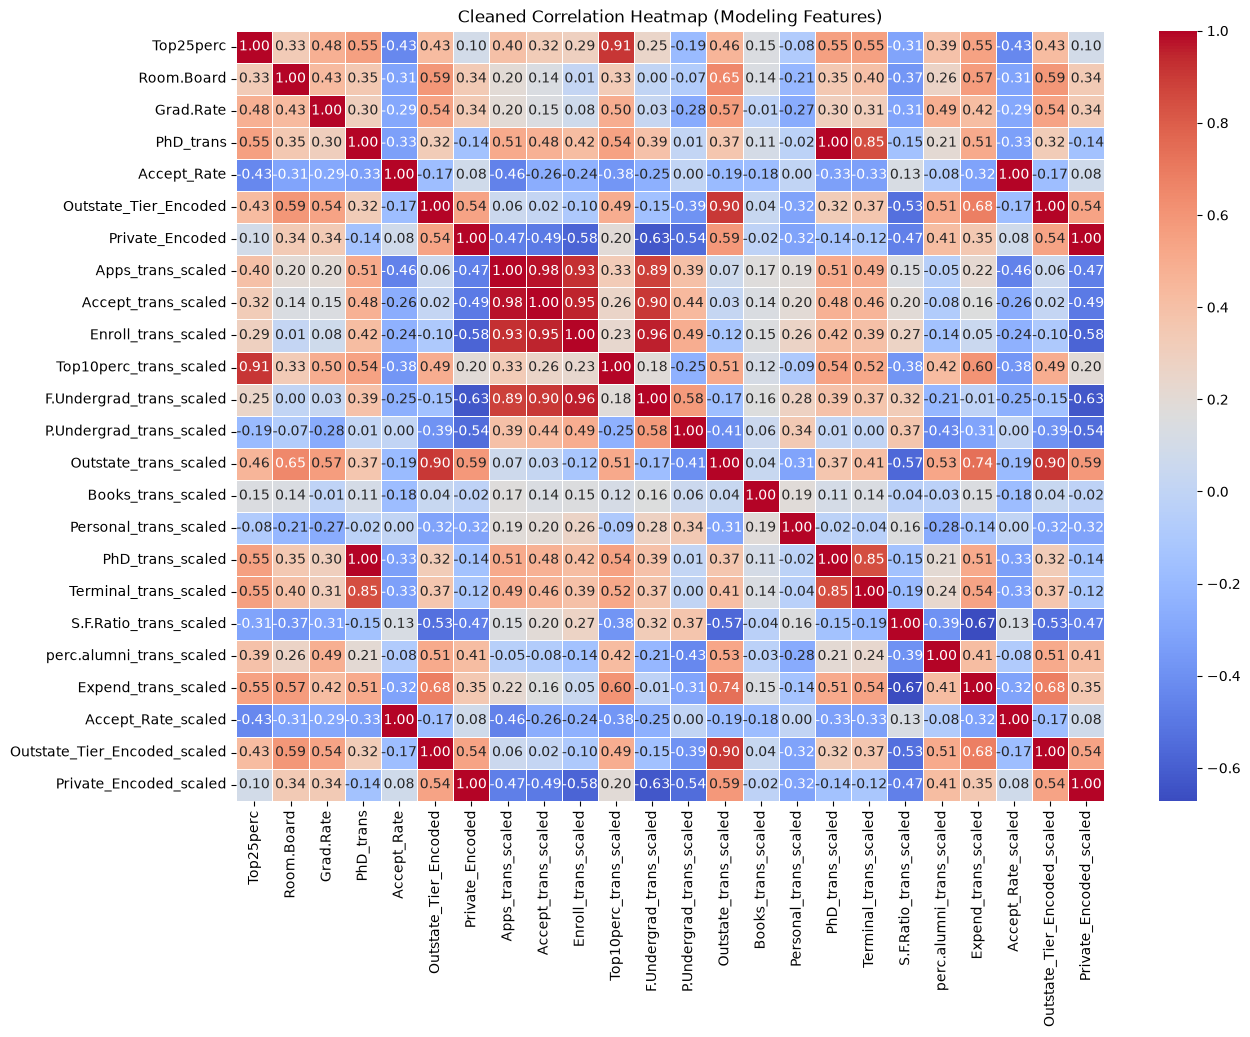

In [112]:
numeric_df_cleaned = df_cleaned.select_dtypes(include=[np.number])

corr_matrix_cleaned = numeric_df_cleaned.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix_cleaned, 
    annot=True,    
    cmap='coolwarm',     
    fmt=".2f", 
    linewidths=0.5
)

plt.title("Cleaned Correlation Heatmap (Modeling Features)")
plt.show()

The features that display the strongest relationship with **Grad.Rate** are:

1. **`Outstate_trans_scaled`** (Correlation: **0.57**)
2. **`Top25perc`** (Correlation: **0.48**) 
3. **`Room.Board`** (Correlation: **0.42**) 

In [113]:
final_drops = [
    'Outstate_Tier_Encoded', 
    'Private_Encoded', 
    'Accept_Rate',
    'Accept_trans_scaled',
    'Enroll_trans_scaled'
]

df_final = df_cleaned.drop(columns=final_drops, errors='ignore')

print("Final clean features remaining for modeling:")
print(df_final.columns.tolist())

Final clean features remaining for modeling:
['Top25perc', 'Room.Board', 'Grad.Rate', 'PhD_trans', 'Apps_trans_scaled', 'Top10perc_trans_scaled', 'F.Undergrad_trans_scaled', 'P.Undergrad_trans_scaled', 'Outstate_trans_scaled', 'Books_trans_scaled', 'Personal_trans_scaled', 'PhD_trans_scaled', 'Terminal_trans_scaled', 'S.F.Ratio_trans_scaled', 'perc.alumni_trans_scaled', 'Expend_trans_scaled', 'Accept_Rate_scaled', 'Outstate_Tier_Encoded_scaled', 'Private_Encoded_scaled']


## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [114]:
y = df_final['Grad.Rate']

In [115]:
X_untransformed = df[['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Private']]

In [116]:
X_untransformed = X_untransformed.copy()
X_untransformed['Private'] = X_untransformed['Private'].map({'Yes': 1, 'No': 0})

In [117]:
X_transformed = df_final.drop(columns=['Grad.Rate'])

In [118]:
X_untransformed = X_untransformed.apply(pd.to_numeric, errors='coerce')
X_untransformed = X_untransformed.fillna(X_untransformed.median())

In [119]:
X_train_un, X_test_un, y_train, y_test = train_test_split(
    X_untransformed, y, test_size=0.2, random_state=42
)

X_train_trans, X_test_trans, _, _ = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42
)

#### 15. Fit a linear regression using the raw predictors


In [120]:
untrans_predictors = []

# Your code here
untrans_predictors = X_untransformed.columns.tolist()

model_un = LinearRegression()
model_un.fit(X_train_un, y_train)

r2_untrans = model_un.score(X_test_un, y_test)
print(f"Raw Predictors R-squared Score: {r2_untrans:.4f}")

Raw Predictors R-squared Score: 0.5063


#### 16. Fit the same model using the log-transformed predictors

In [121]:
trans_predictors = []

# Your code here

trans_predictors = X_transformed.columns.tolist()

model_trans = LinearRegression()
model_trans.fit(X_train_trans, y_train)

r2_trans = model_trans.score(X_test_trans, y_test)
print(f"Transformed Predictors R-squared Score: {r2_trans:.4f}")

Transformed Predictors R-squared Score: 0.5064


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [122]:
# Your code here 
print(f"Original Data R2 Score:    {r2_untrans:.4f}")
print(f"Transformed Data R2 Score: {r2_trans:.4f}")

improvement = r2_trans - r2_untrans
if improvement > 0:
    print(f"\nYes! The results improved by {improvement:.4f} in R-squared score.")
else:
    print(f"\nNo major performance increase observed (Change: {improvement:.4f}).")

Original Data R2 Score:    0.5063
Transformed Data R2 Score: 0.5064

Yes! The results improved by 0.0001 in R-squared score.


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [123]:
# Your code here 
df_final.to_csv("./data/college_transformed.csv", index=False)